In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [ ]:
df.shape


(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


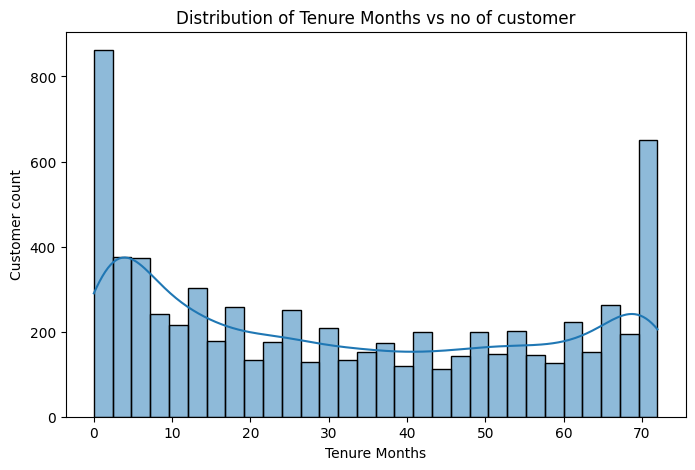

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

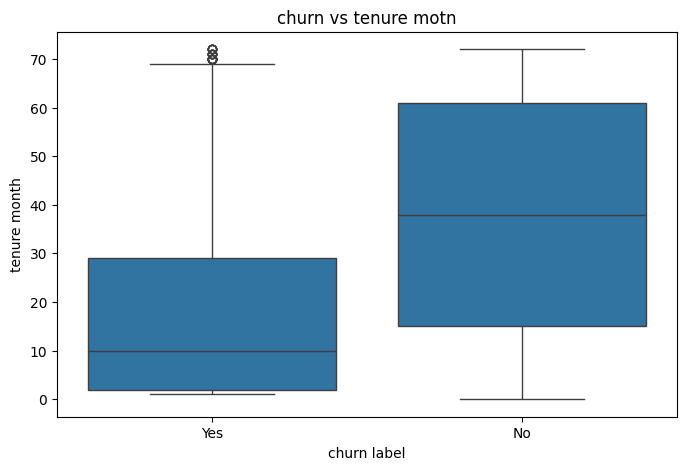

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months' , data=df)
plt.xlabel('churn label')
plt.ylabel('tenure month')
plt.title('churn vs tenure motn')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

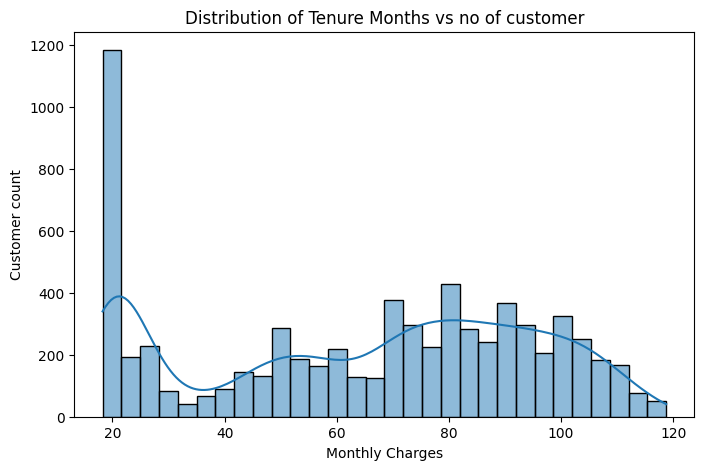

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

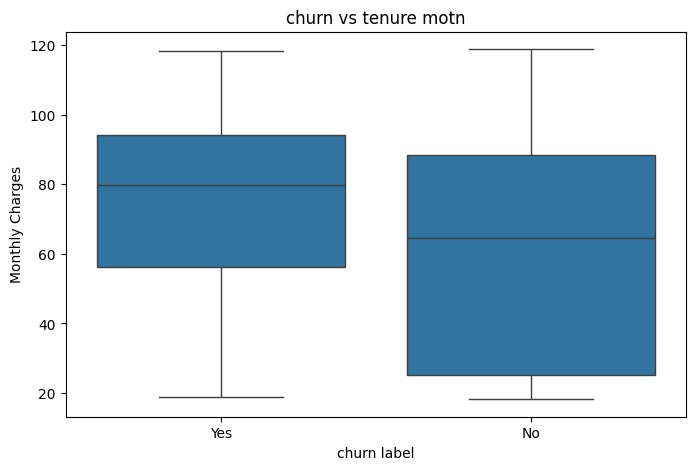

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges' , data=df)
plt.xlabel('churn label')
plt.ylabel('Monthly Charges')
plt.title('churn vs tenure motn')
plt.show()

In [ ]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25, 0.5, 0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

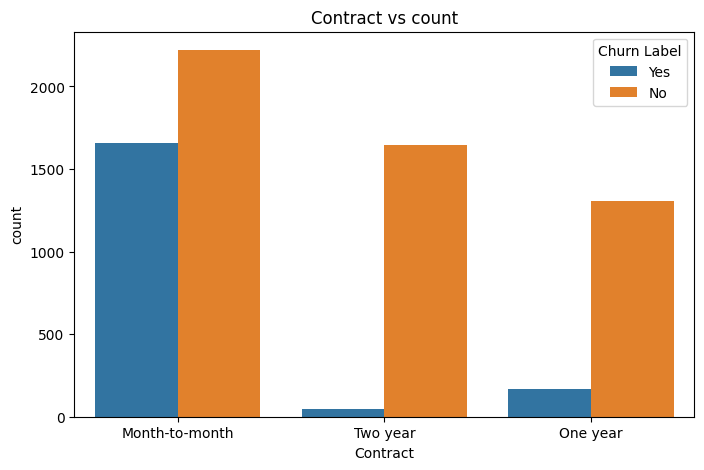

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Contract vs count')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Internet Service'].unique(
)

array(['DSL', 'Fiber optic', 'No'], dtype=object)

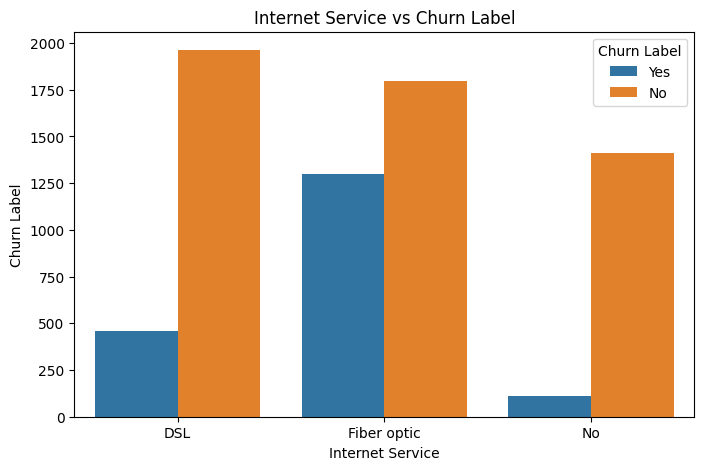

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service',hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('Churn Label')
plt.title('Internet Service vs Churn Label')
plt.show()

In [ ]:
df['Payment Method'].unique(
)

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

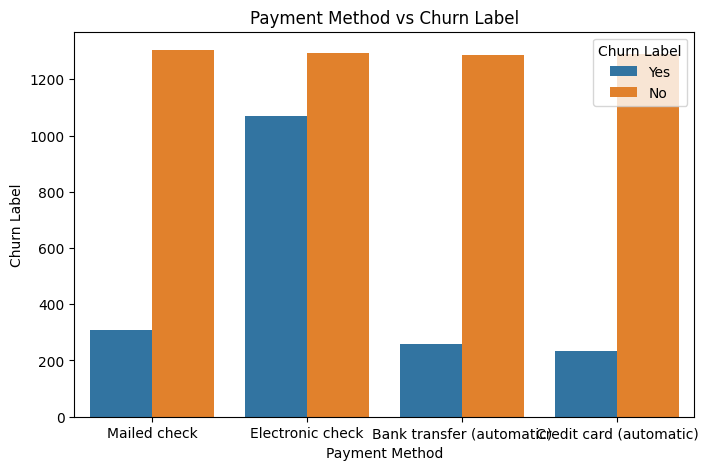

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method',hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('Churn Label')
plt.title('Payment Method vs Churn Label')
plt.show()

In [ ]:
df['Tech Support'].unique(
)

array(['No', 'Yes', 'No internet service'], dtype=object)

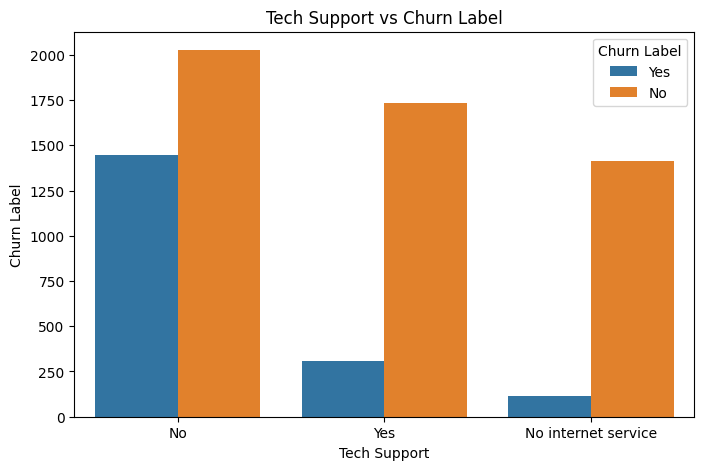

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support',hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('Churn Label')
plt.title('Tech Support vs Churn Label')
plt.show()

In [ ]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [ ]:
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [ ]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value', 'Churn Score', 'CLTV']
correlation_matrix=df[numerical_cols].corr()

In [ ]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [ ]:
contact_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contact_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Data cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [ ]:
df['Total Charges']=df['Total Charges'].fillna(0)
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [ ]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','City','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [ ]:
df = df.drop(columns=drop_columns)

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 31)

In [ ]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
X = df_encoded.drop('Churn Value', axis=1)
Y = df_encoded['Churn Value']

In [ ]:
X.shape
Y.shape

(7043,)

In [ ]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [ ]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


ML implimentation

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42)

In [ ]:
X_train.shape

(5634, 30)

In [ ]:
X_test.shape

(1409, 30)

In [ ]:
Y_train.shape

(5634,)

In [ ]:
Y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_modal = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
rf_modal.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_modal.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_test = accuracy_score(Y_test, y_pred)
accuracy_test

0.7856635911994322

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(Y_test, y_pred)

array([[902, 107],
       [195, 205]])

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 1- Handle class imbalance

In [ ]:
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced = rf_balanced.predict(X_test)
accuracy_test = accuracy_score(Y_test, y_pred_balanced)
confusion_matrix(Y_test, y_pred_balanced)
print(classification_report(Y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 2- Hyper peramiter tunning

In [ ]:
rf_tunned = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tunned.fit(X_train,Y_train)
y_pred_tunned = rf_tunned.predict(X_test)
print(classification_report(Y_test, y_pred_tunned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



Approach 3-Feature important analysis

In [ ]:
import pandas as pd
feature_importance =pd.DataFrame({
    'featurs' : X.columns,
    'importance' : rf_tunned.feature_importances_
})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)
print(feature_importance)

                                   featurs  importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [ ]:
print(feature_importance.tail(15))

                                   featurs  importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


In [ ]:
droping = ['Phone Service_Yes', 'Multiple Lines_No phone service','Streaming TV_Yes','Streaming Movies_Yes','Device Protection_No internet service']
X_selected = X.drop(droping,axis=1)

In [ ]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.20, random_state=42)

In [ ]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_sel = rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel, y_pred_sel))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409



Approach 2-combination of tree and depth

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier

In [ ]:
n_estimators_list = [100,200,300,400,500]
max_depth_list = [5,10,15,20,25]
result = []
for n_tree in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_tree, max_depth=depth, random_state=42, class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    result.append({'Tree': n_tree, 'Depth': depth, 'Accuracy': accuracy,'Recall': recall, 'Precision': precision, 'F1': f1})
result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by=['Recall', 'Accuracy'], ascending=False)
print(result_df.head(20))

    Tree  Depth  Accuracy  Recall  Precision        F1
0    100      5  0.745919  0.8200   0.534202  0.646943
10   300      5  0.743790  0.8200   0.531605  0.645034
15   400      5  0.743790  0.8125   0.531915  0.642928
5    200      5  0.742370  0.8100   0.530278  0.640950
20   500      5  0.740951  0.8050   0.528736  0.638256
1    100     10  0.775727  0.7525   0.581081  0.655773
11   300     10  0.782825  0.7475   0.593254  0.661504
16   400     10  0.782825  0.7475   0.593254  0.661504
21   500     10  0.781405  0.7475   0.590909  0.660044
6    200     10  0.782115  0.7450   0.592445  0.660022
12   300     15  0.806246  0.6400   0.664935  0.652229
17   400     15  0.803407  0.6375   0.658915  0.648030
22   500     15  0.801987  0.6375   0.655527  0.646388
7    200     15  0.804826  0.6350   0.663185  0.648787
2    100     15  0.802697  0.6300   0.659686  0.644501
3    100     20  0.787793  0.5325   0.655385  0.587586
8    200     20  0.793471  0.5275   0.674121  0.591865
4    100  

In [ ]:
#from sklearn.model_selection import cross_val_score
#final_rf=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')


In [ ]:
#cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')
#cv_accuracy

In [ ]:
#cv_accuracy.mean()

In [ ]:
#cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')
#cv_recall

In [ ]:
#cv_recall.mean()

Optinal (for checking perpose)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
y_prob1=rf_tunned.predict_proba(X_test)

In [ ]:
churn_prob=y_prob1[:,1]
fpr,tpr,threshold = roc_curve(Y_test,churn_prob)
auc_score = roc_curve(Y_test,churn_prob)
print(auc_score)

(array([0.00000000e+00, 9.91080278e-04, 9.91080278e-04, 1.98216056e-03,
       1.98216056e-03, 2.97324083e-03, 2.97324083e-03, 3.96432111e-03,
       3.96432111e-03, 3.96432111e-03, 3.96432111e-03, 4.95540139e-03,
       4.95540139e-03, 5.94648167e-03, 5.94648167e-03, 7.92864222e-03,
       7.92864222e-03, 8.91972250e-03, 8.91972250e-03, 9.91080278e-03,
       9.91080278e-03, 1.09018831e-02, 1.09018831e-02, 1.18929633e-02,
       1.18929633e-02, 1.38751239e-02, 1.38751239e-02, 1.58572844e-02,
       1.58572844e-02, 1.98216056e-02, 1.98216056e-02, 2.08126858e-02,
       2.08126858e-02, 2.37859267e-02, 2.37859267e-02, 2.47770069e-02,
       2.47770069e-02, 2.57680872e-02, 2.57680872e-02, 2.67591675e-02,
       2.67591675e-02, 2.77502478e-02, 2.77502478e-02, 2.87413280e-02,
       2.87413280e-02, 2.97324083e-02, 2.97324083e-02, 3.07234886e-02,
       3.07234886e-02, 3.17145689e-02, 3.17145689e-02, 3.46878097e-02,
       3.46878097e-02, 3.56788900e-02, 3.56788900e-02, 3.86521308e-02,
     

**Customer Segmentation**

In [ ]:
y_prob=rf_tunned.predict_proba(X)
churn_probability= y_prob[:,1]
segmentation_data=pd.DataFrame({
  'Tenure Months':X['Tenure Months'],
  'Monthly Charges':X['Monthly Charges'],
  'Total Charges':X['Total Charges'],
  'Churn Probability':churn_probability})
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


**Implimentation of Kmeans**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


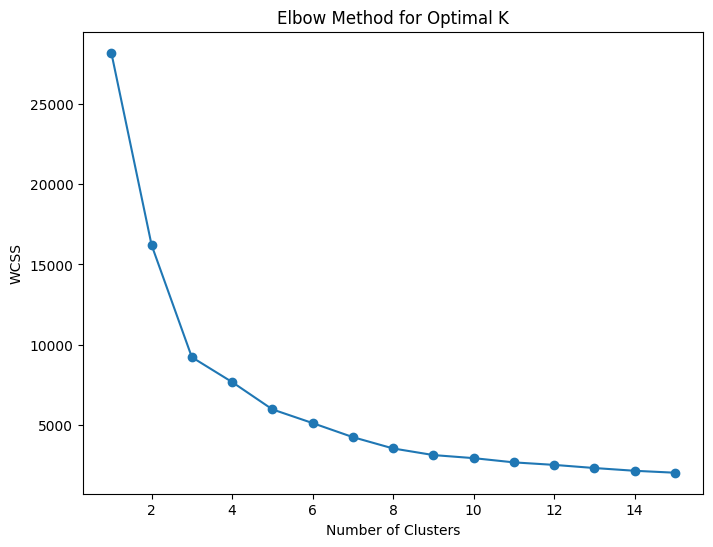

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1,16):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data['Cluster'] = clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [ ]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [ ]:
cluster_name = {
    0:"Budget Loyal customer",
    1:"High risk customer",
    2:"Loyal premium customer"
}

In [ ]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_name)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High risk customer
1,2,70.70,151.65,0.796013,1,High risk customer
2,8,99.65,820.50,0.805827,1,High risk customer
3,28,104.80,3046.05,0.563031,1,High risk customer
4,49,103.70,5036.30,0.517474,2,Loyal premium customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal customer
7039,24,84.80,1990.50,0.082095,0,Budget Loyal customer
7040,72,103.20,7362.90,0.049001,2,Loyal premium customer
7041,11,29.60,346.45,0.302367,0,Budget Loyal customer


<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

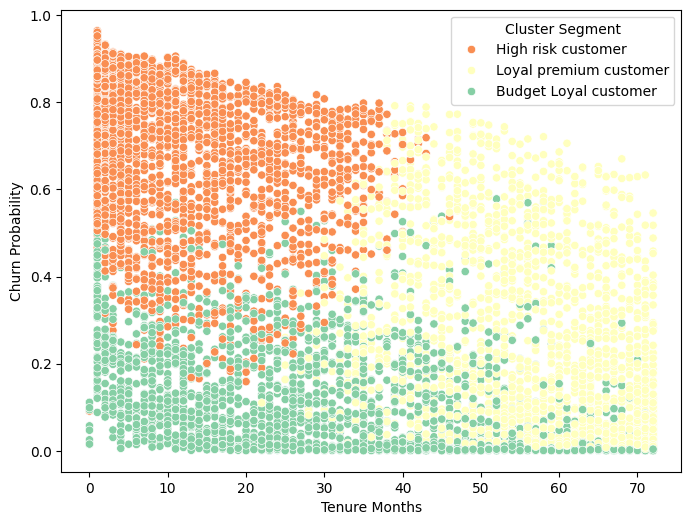

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data,palette='Spectral')

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

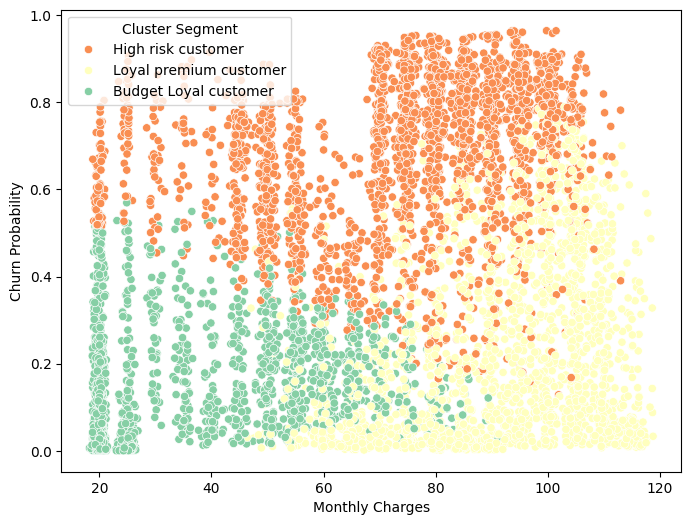

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data,palette='Spectral')